In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

class_names = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

print("Straight from load_data():", x_train.shape)

x_train = x_train / 255.0
x_test = x_test / 255.0

Straight from load_data(): (60000, 28, 28)


In [ ]:
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

print("After adding a channel: ", x_train.shape)

After adding a channel:  (60000, 28, 28, 1)


In [ ]:
x_train, y_train = x_train[:10000], y_train[:10000]
x_test, y_test = x_test[:2000], y_test[:2000]

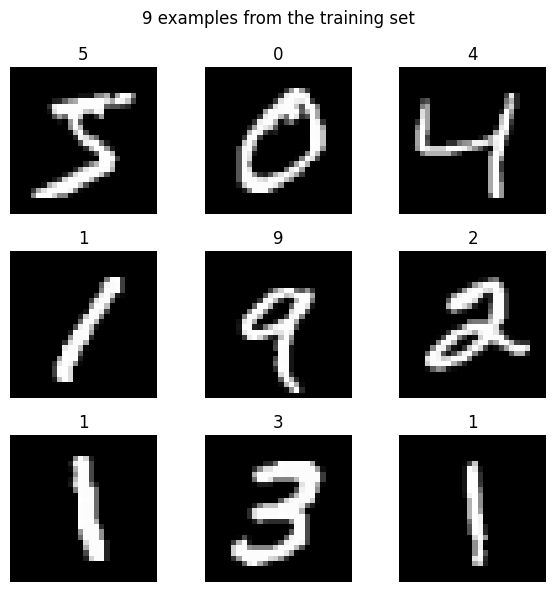

In [ ]:
plt.figure(figsize=(6, 6))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.suptitle("9 examples from the training set")
plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.layers import Dropout, Input, BatchNormalization

model = Sequential([
    Input(shape=(28, 28, 1)),

    Conv2D(32, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 391,306 (1.49 MB)

 Trainable params: 390,858 (1.49 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
model.compile(optimizer='rmsprop',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Training the model using the optimizer defined in the previous cell
history = model.fit(x_train, y_train,
                    epochs=10000,
                    batch_size=64,
                    validation_split=0.2)

Epoch 1/10000
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8994 - loss: 0.3342 - val_accuracy: 0.1105 - val_loss: 5.3304
Epoch 2/10000
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9634 - loss: 0.1299 - val_accuracy: 0.1115 - val_loss: 9.7504
Epoch 3/10000
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9741 - loss: 0.0905 - val_accuracy: 0.4720 - val_loss: 2.7332
Epoch 4/10000
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9821 - loss: 0.0621 - val_accuracy: 0.8820 - val_loss: 0.4811
Epoch 5/10000
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9870 - loss: 0.0404 - val_accuracy: 0.9725 - val_loss: 0.1188
Epoch 6/10000
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9893 - loss: 0.0395 - val_accuracy: 0.9760 - val_loss: 0.0980
Epoch 7/10000
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9909 - loss: 0.0316 - val_accuracy: 0.9800 - val_loss: 0.0882
Epoch 8/10000
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9914 - loss: 

KeyboardInterrupt: 

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nAccuracy on unseen test images: {test_acc:.2%}")

In [ ]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Did it learn?')
plt.legend()
plt.show()

In [ ]:
i = np.random.randint(0, len(x_test))
image = x_test[i]
true_label = class_names[y_test[i]]

In [ ]:
probabilities = model.predict(image[np.newaxis, ...], verbose=0)[0]

predicted_label = class_names[np.argmax(probabilities)]
confidence = np.max(probabilities)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.imshow(image.squeeze(), cmap='gray')
ax1.axis('off')
color = 'green' if predicted_label == true_label else 'red'
ax1.set_title(f"Guess: {predicted_label} ({confidence:.0%})\nTruth: {true_label}", color=color)

ax2.barh(class_names, probabilities)
ax2.set_xlim(0, 1)
ax2.set_xlabel('Probability')
ax2.set_title("How sure was the model?")

plt.tight_layout()
plt.show()

In [ ]:
model.save("cnn.keras")

In [ ]:
from keras.models import load_model
model2=load_model("cnn.keras")

In [ ]:
test_loss2, test_acc2 = model2.evaluate(x_test, y_test, verbose=0)
print(f"\nAccuracy of model2 on unseen test images: {test_acc2:.2%}")

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os

image_path = '/content/Screenshot 2026-07-27 202752.png'

# Check if file exists and load it directly
if os.path.exists(image_path):
    img = Image.open(image_path).convert('L') # Convert to grayscale
    img = img.resize((28, 28))

    # Convert image to numpy array and normalize
    img_array = np.array(img) / 255.0

    print(f"Image loaded from {image_path}. Shape: {img_array.shape}")

    # Display the loaded image
    plt.imshow(img_array, cmap='gray')
    plt.title("Loaded Image from File")
    plt.axis('off')
    plt.show()

    # Add batch and channel dimensions for the model input
    processed_image = img_array[np.newaxis, ..., np.newaxis]
    print("Processed image shape:", processed_image.shape)

    # Predict using model2
    probabilities2 = model2.predict(processed_image, verbose=0)[0]
    predicted_label2 = class_names[np.argmax(probabilities2)]
    confidence2 = np.max(probabilities2)

    # Plot results
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.imshow(img_array, cmap='gray')
    ax1.axis('off')
    ax1.set_title(f"Model2 Guess: {predicted_label2} ({confidence2:.0%})")

    ax2.barh(class_names, probabilities2)
    ax2.set_xlim(0, 1)
    ax2.set_xlabel('Probability')
    ax2.set_title("How sure was Model2?")
    plt.tight_layout()
    plt.show()
else:
    print(f"Error: The file {image_path} was not found. Please ensure it is uploaded to the /content/ folder.")